<a href="https://colab.research.google.com/github/Slautin/2025_vae_dkl/blob/main/1.1_pureVAE_card_dataset_with_VAE_GP_extended.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#VAE model: card dataset

February 2025

Supporting codes for the manuscript: **Integrating Predictive and Generative Capabilities by Latent Space Design via the DKL-VAE model**

*Notebook 1 of 3*

This Notebook presents an analysis of the latent space structure learned by a Variational Autoencoder (VAE) trained on both the complete card suit dataset and a subset of it.

* Author [Boris Slautin](https://scholar.google.com/citations?hl=ru&view_op=list_works&gmla=AH70aAU_JtxEIQgg_RTLPnUSZHKp1J1iDrJUxTZ7Dzw5p5jEtCEug5zMWLCh4A-pe5ekW_9a_aXHOSIjEp-2UT_kypL9DfD7GcD76qEpeOzSkAibBjmm_7RL&user=Y2AXABsAAAAJ)

* [Pyroved](https://pyroved.readthedocs.io/en/latest/) package by [Maxim Ziatdinov](https://scholar.google.com/citations?user=YnSdOoUAAAAJ&hl=en)

* Project lead and supervision by [Sergei V. Kalinin](https://scholar.google.com/citations?hl=en&user=-cuxoSQAAAAJ&view_op=list_works&sortby=pubdate)


In [1]:
!pip install git+https://github.com/ziatdinovmax/pyroved.git;
!pip install -q kornia;

  Cloning https://github.com/ziatdinovmax/pyroved.git to /tmp/pip-req-build-_zz86ems
  Running command git clone --filter=blob:none --quiet https://github.com/ziatdinovmax/pyroved.git /tmp/pip-req-build-_zz86ems
  Resolved https://github.com/ziatdinovmax/pyroved.git to commit 7807ffb1cb415b3cc76c1e02d52465a8ae0eeae4
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 12.2 MB/s eta 0:00:00
  Created wheel for pyroved: filename=pyroved-0.3.0-py3-none-any.whl size=50258 sha256=1131a555198842d75971a3ecb9ca84fed624ba8ae02e988cf86804d1ecbe2bf5
  Stored in directory: /tmp/pip-ephem-wheel-cache-667zo5e_/wheels/79/9c/90/d941a65b87a324112508ee1058d09743741029a74b5fa0f1f6
Successfully built pyroved
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 66.3 MB/s eta 0:00:00


In [2]:
import math
import numpy as np

import torch
import torch.nn as nn
import kornia as K

import cv2

import pyroved as pv
import matplotlib.pyplot as plt


tt = torch.tensor

In [3]:
#arbitrary functions
resize = lambda x: cv2.resize(x, (64, 64), cv2.INTER_CUBIC)

def get_data():
    card1 = resize(cv2.imread("cards/card1.JPG", cv2.IMREAD_GRAYSCALE))
    card2 = resize(cv2.imread("cards/card2.JPG", cv2.IMREAD_GRAYSCALE))
    card3 = resize(cv2.imread("cards/card3.JPG", cv2.IMREAD_GRAYSCALE))
    card4 = resize(cv2.imread("cards/card4.JPG", cv2.IMREAD_GRAYSCALE))
    card1 = tt(1 - card1 / card1.max())
    card2 = tt(1 - card2 / card2.max())
    card3 = tt(1 - card3 / card3.max())
    card4 = tt(1 - card4 / card4.max())
    return card1, card2, card3, card4

def transform_imgs(cards, **kwargs):
    np.random.seed(0)
    torch.manual_seed(0)

    a = kwargs.get("angle")
    t = kwargs.get("translation")
    s = (kwargs.get("shear"))
    if s is not None:
        s = math.radians(s)


    n_samples = kwargs.get("samples", 3000)
    n_samples_total = n_samples*4

    card1, card2, card3, card4 = cards[0], cards[1], cards[2], cards[3]

    card1 = card1[None, None].repeat_interleave(n_samples, dim = 0)
    card2 = card2[None, None].repeat_interleave(n_samples, dim = 0)
    card3 = card3[None, None].repeat_interleave(n_samples, dim = 0)
    card4 = card4[None, None].repeat_interleave(n_samples, dim = 0)

    cards_all = torch.cat((card1, card2, card3, card4), dim = 0)

    angles = tt(np.random.uniform(low = -a, high = a, size = [n_samples_total]))
    translations = tt(np.random.uniform(low = -t, high = t, size = [n_samples_total,1])).repeat_interleave(2, dim = 1)
    shears = tt(np.random.uniform(low = -s, high = s, size = [n_samples_total, 1])).repeat_interleave(2, dim = 1)

    transform = nn.Sequential(
        K.augmentation.CenterCrop((48, 48)),
        K.geometry.Affine(angle = angles, translation = translations,
                          shear = shears)
    )

    cards = transform(cards_all).squeeze().float()
    labels = torch.cat([torch.zeros(len(card1)), torch.ones(len(card2)),
                           2*torch.ones(len(card3)), 3*torch.ones(len(card4))])
    return cards, labels, angles, translations, shears

# Step 1: Import and Preprocess the Card Suit Dataset

In [4]:
# Download the cards dataset
!gdown -q https://drive.google.com/uc?id=1AyGHVflbIjzinkKBURHNVDx1wWg9JixB
!unzip -o -qq cards.zip

In [5]:
#@title Helper functions that apply afffine transformations to the dataset
rs = lambda x: cv2.resize(x, (64, 64), cv2.INTER_CUBIC)

def get_data():
    card1 = rs(cv2.imread("cards/card1.JPG", cv2.IMREAD_GRAYSCALE))
    card2 = rs(cv2.imread("cards/card2.JPG", cv2.IMREAD_GRAYSCALE))
    card3 = rs(cv2.imread("cards/card3.JPG", cv2.IMREAD_GRAYSCALE))
    card4 = rs(cv2.imread("cards/card4.JPG", cv2.IMREAD_GRAYSCALE))
    card1 = tt(1 - card1 / card1.max())
    card2 = tt(1 - card2 / card2.max())
    card3 = tt(1 - card3 / card3.max())
    card4 = tt(1 - card4 / card4.max())
    return card1, card2, card3, card4


import math
def transform_imgs(cards, **kwargs):
    np.random.seed(0)
    torch.manual_seed(0)

    a = kwargs.get("angle")
    t = kwargs.get("translation")
    s = (kwargs.get("shear"))
    if s is not None:
        s = math.radians(s)


    n_samples = kwargs.get("samples", 3000)
    n_samples_total = n_samples*4

    card1, card2, card3, card4 = cards[0], cards[1], cards[2], cards[3]

    card1 = card1[None, None].repeat_interleave(n_samples, dim = 0)
    card2 = card2[None, None].repeat_interleave(n_samples, dim = 0)
    card3 = card3[None, None].repeat_interleave(n_samples, dim = 0)
    card4 = card4[None, None].repeat_interleave(n_samples, dim = 0)

    cards_all = torch.cat((card1, card2, card3, card4), dim = 0)

    angles = tt(np.random.uniform(low = -a, high = a, size = [n_samples_total]))
    translations = tt(np.random.uniform(low = -t, high = t, size = [n_samples_total,1])).repeat_interleave(2, dim = 1)
    shears = tt(np.random.uniform(low = -s, high = s, size = [n_samples_total, 1])).repeat_interleave(2, dim = 1)

    transform = nn.Sequential(
        K.augmentation.CenterCrop((48, 48)),
        K.geometry.Affine(angle = angles, translation = translations,
                          shear = shears)
    )

    cards = transform(cards_all).squeeze().float()
    labels = torch.cat([torch.zeros(len(card1)), torch.ones(len(card2)),
                           2*torch.ones(len(card3)), 3*torch.ones(len(card4))])
    return cards, labels, angles, translations, shears


def plot_manifolds(model):
    fig, axes = plt.subplots(2, 2, figsize=(12, 12),
                            subplot_kw={'xticks':[], 'yticks':[]},
                            gridspec_kw=dict(hspace=0.1, wspace=0.05))
    for i, ax in enumerate(axes.flat):
        manifold = model.manifold2d(d=9, label=i, plot=False)
        grid = make_grid(manifold[:, None], nrow=9, pad_value=.5)
        ax.imshow(grid[0], cmap='viridis')
    plt.show()


def rearrange_manifold(dat):
  grid_size = int(np.sqrt(dat.shape[0]))  # 10 x 10 grid for 100 slices
  rows = grid_size * dat.shape[1]  # 10 * 48 = 480
  cols = grid_size * dat.shape[2]  # 10 * 48 = 480

  # Rearrange into 2D grid
  rearranged = (dat.reshape(grid_size, grid_size, dat.shape[1], dat.shape[2])
                .flip(0)
                .flip(1)
                .permute(1, 2, 0, 3)  # Rearrange axes for proper stacking
                .reshape(rows, cols)
                )  # Combine into 2D array

  # Convert to NumPy array
  rearranged_np = rearranged.numpy()
  return rearranged_np

In [6]:
#@title functions for saving data

def convert_to_supported_dtype(arr):
    # Check if array has an object dtype
    if arr.dtype == np.dtype('O'):
        # Attempt conversion to a compatible type (if possible)
        try:
            return arr.astype(np.float64)  # Change to a compatible type (e.g., float)
        except ValueError:
            raise ValueError(f"Cannot convert array '{arr}' to a supported dtype.")
    return arr

def save_dict_to_hdf5(file_path, data_dict):
    def save_data(group, data):
        for key, value in data.items():
            if isinstance(value, dict):
                subgroup = group.create_group(key)
                save_data(subgroup, value)
            elif isinstance(value, np.ndarray):
                # Check and convert object dtype arrays if needed
                value = convert_to_supported_dtype(value)
                group.create_dataset(key, data=value)
            else:
                group.create_dataset(key, data=value)
    with h5py.File(file_path, 'w') as f:
        save_data(f, data_dict)

def load_hdf5_to_dict(file_path):
    def load_data(group):
        data = {}
        for key, item in group.items():
            if isinstance(item, h5py.Group):
                data[key] = load_data(item)
            else:
                data[key] = np.array(item)
        return data

    with h5py.File(file_path, 'r') as f:
        data_dict = load_data(f)

    return data_dict

In [7]:
cards = get_data()
cards_all, labels_all, angles_all, translations_all, shears_all = transform_imgs(cards, angle = 30, translation = 0.1, shear = 10, samples = 750)

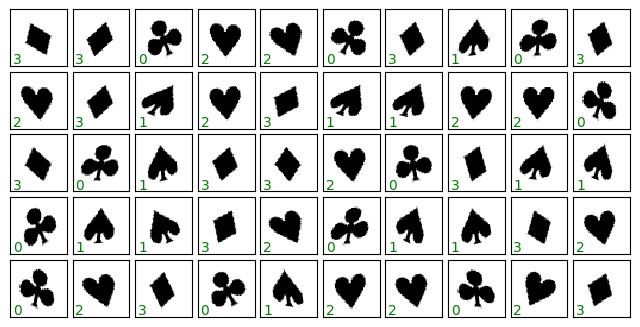

In [8]:
#examples of the card suits
fig, axes = plt.subplots(5, 10, figsize=(8, 4),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))

indd = np.random.choice(np.arange(len(cards_all)), size=150, replace=False)

for ax, im, lbv in zip(axes.flat, cards_all[indd], labels_all[indd]):
    ax.imshow(im.squeeze(), cmap='binary', interpolation='nearest')
    ax.text(0.05, 0.05, str(int(lbv)),
            transform=ax.transAxes, color='green')

#2. Train the VAE model on the full dataset

In [9]:
ws = 48
data_dim = (ws, ws)

model = pv.models.iVAE(data_dim, 2)
trainer = pv.trainers.SVItrainer(model)
dataloader = pv.utils.init_dataloader(cards_all.reshape(-1, ws* ws), batch_size=100)

In [10]:
figs = []
for e in range(1500):
    trainer.step(dataloader, train_vae=True)
    trainer.print_statistics()
    #verbose
    # if (e+1) % 50 == 0:
    #     model.manifold2d(d=12)
    #     z_loc, _ = model.encode(cards_all.reshape(-1, ws* ws))

    #     fig,ax = plt.subplots(1,2, figsize=(10,4))

    #     im = ax[0].scatter(z_loc[:, -2], z_loc[:, -1], s=5, c=labels_all, cmap='jet')
    #     cbar = fig.colorbar(im, ax=ax[0], shrink=.8)
    #     im = ax[1].scatter(z_loc[:, -2], z_loc[:, -1], s=5, c=angles_all, cmap='jet')
    #     cbar = fig.colorbar(im, ax=ax[1], shrink=.8)

    #     for _ in ax:
    #       _.set_xlabel('$z_1$', fontsize=14)
    #       _.grid()

    #     ax[0].set_title('Suits')
    #     ax[1].set_title('Shears')
    #     ax[0].set_ylabel('$z_2$', fontsize=14)

    #     plt.show()
    #     figs.append(fig)


Epoch: 1 Training loss: 943.4480
Epoch: 2 Training loss: 413.2000
Epoch: 3 Training loss: 394.2762
Epoch: 4 Training loss: 387.9524
Epoch: 5 Training loss: 382.4384
Epoch: 6 Training loss: 375.0119
Epoch: 7 Training loss: 360.2709
Epoch: 8 Training loss: 343.9493
Epoch: 9 Training loss: 335.2963
Epoch: 10 Training loss: 330.2037
Epoch: 11 Training loss: 326.0945
Epoch: 12 Training loss: 320.1950
Epoch: 13 Training loss: 310.3888
Epoch: 14 Training loss: 296.4157
Epoch: 15 Training loss: 286.9546
Epoch: 16 Training loss: 280.8943
Epoch: 17 Training loss: 276.0515
Epoch: 18 Training loss: 272.3756
Epoch: 19 Training loss: 267.9978
Epoch: 20 Training loss: 262.9330
Epoch: 21 Training loss: 255.4838
Epoch: 22 Training loss: 246.2793
Epoch: 23 Training loss: 237.3503
Epoch: 24 Training loss: 229.3412
Epoch: 25 Training loss: 222.7722
Epoch: 26 Training loss: 217.1199
Epoch: 27 Training loss: 212.3205
Epoch: 28 Training loss: 208.2237
Epoch: 29 Training loss: 204.2622
Epoch: 30 Training loss

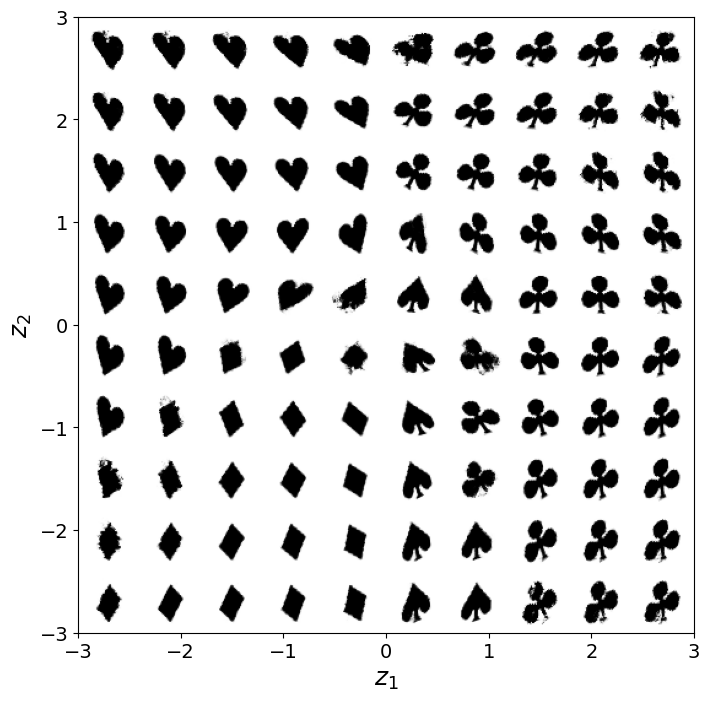

In [11]:
mf = model.manifold2d(d=10, cmap='binary', z_coord=[-3,3,-3,3], dpi=50)

mf_np = rearrange_manifold(mf)

/tmp/ipykernel_2911/1832423439.py:15: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  scatter = ax[1].scatter(z_loc[indices, -2].numpy(), z_loc[indices, -1].numpy(),


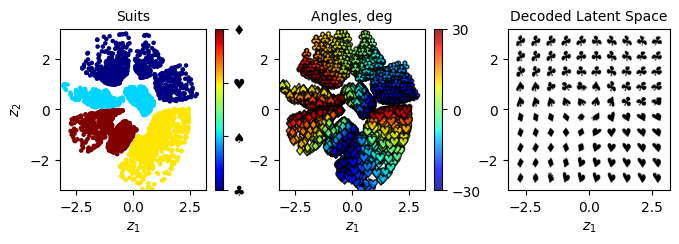

In [12]:
suits = ['♣', '♠', '♥', '♦', ]  # Card suits
suit_markers = {0: '♣', 1: '♠', 2: '♥', 3: '♦'}
z_loc, _ = model.encode(cards_all.reshape(-1, ws* ws))

fig,ax = plt.subplots(1,3, figsize=(8,2.1))

im = ax[0].scatter(z_loc[:, -2], z_loc[:, -1], s=5, c=labels_all, cmap='jet')
cbar = fig.colorbar(im, ax=ax[0])
cbar.set_ticks(np.linspace(0, 3, len(suits)))  # Set positions of labels
cbar.set_ticklabels(suits)
ax[0].set_title('Suits', fontsize=10)

for suit_id, suit_marker in suit_markers.items():
  indices = np.where(labels_all == suit_id)
  scatter = ax[1].scatter(z_loc[indices, -2].numpy(), z_loc[indices, -1].numpy(),
             label=suit_marker, s=40, alpha=0.8, edgecolors='black',
             marker='$' + suit_marker + '$',
             c = angles_all[indices],
             vmin=-30,
             vmax=30,
             cmap='jet')

cbar = fig.colorbar(scatter, ax=ax[1])
cbar.set_ticks([-30,0,30])
ax[1].set_title('Angles, deg', fontsize=10)

ax[2].imshow(mf_np, cmap='binary', extent = [-3,3,-3,3])
ax[2].set_title('Decoded Latent Space', fontsize=10)

ax[0].set_xlabel('$z_1$', fontsize=10)
ax[1].set_xlabel('$z_1$', fontsize=10)
ax[2].set_xlabel('$z_1$', fontsize=10)
ax[0].set_ylabel('$z_2$', fontsize=10)

for _ in ax:
  _.set_xlim(-3.2,3.2)
  _.set_ylim(-3.2,3.2)

#plt.tight_layout()
fig.savefig('full_vae.jpg', dpi=300, bbox_inches='tight')

#3. Train the VAE model on the subset

In [13]:
threshold = 0
threshold1 = 15
cards_train = cards_all[(angles_all < threshold) | (angles_all > threshold1)]
labels_train = labels_all[(angles_all < threshold) | (angles_all > threshold1)]
translations_train = translations_all[(angles_all < threshold) | (angles_all > threshold1)]
shears_train = shears_all[(angles_all < threshold) | (angles_all > threshold1)]
angles_train = angles_all[(angles_all < threshold) | (angles_all > threshold1)]

cards_test = cards_all[(angles_all > threshold) & (angles_all < threshold1)]
labels_test = labels_all[(angles_all > threshold) & (angles_all < threshold1)]
translations_test = translations_all[(angles_all > threshold) & (angles_all < threshold1)]
shears_test = shears_all[(angles_all > threshold) & (angles_all < threshold1)]
angles_test = angles_all[(angles_all > threshold) & (angles_all < threshold1)]

Text(0, 0.5, 'Counts')

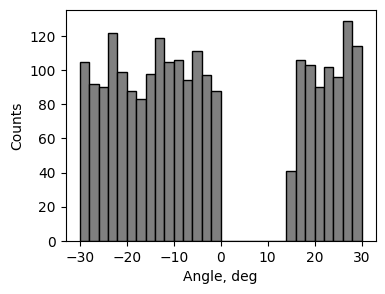

In [14]:
fig = plt.figure(figsize=(4,3))
_ = plt.hist(angles_train, bins=30, range=(-30,30), edgecolor='black', color='grey')
plt.xlabel('Angle, deg')
plt.ylabel('Counts')

In [15]:
ws = 48
data_dim = (ws, ws)

model = pv.models.iVAE(data_dim, 2)
trainer = pv.trainers.SVItrainer(model)
dataloader = pv.utils.init_dataloader(cards_train.reshape(-1, ws* ws), batch_size=100)

In [16]:
figs = []
for e in range(1500):
    trainer.step(dataloader, train_vae=False)
    trainer.print_statistics()
    #visualize
    # if (e+1) % 50 == 0:
    #     model.manifold2d(d=12)

    #     z_loc, _ = model.encode(cards_all.reshape(-1, ws* ws))

    #     fig,ax = plt.subplots(1,2, figsize=(10,4))

    #     im = ax[0].scatter(z_loc[:, -2], z_loc[:, -1], s=5, c=labels_all, cmap='jet')
    #     cbar = fig.colorbar(im, ax=ax[0], shrink=.8)
    #     im = ax[1].scatter(z_loc[:, -2], z_loc[:, -1], s=5, c=angles_all, cmap='jet')
    #     cbar = fig.colorbar(im, ax=ax[1], shrink=.8)

    #     for _ in ax:
    #       _.set_xlabel('$z_1$', fontsize=14)
    #       _.grid()

    #     ax[0].set_title('Suits')
    #     ax[1].set_title('Angles')
    #     ax[0].set_ylabel('$z_2$', fontsize=14)

    #     plt.show()
    #     figs.append(fig)

Epoch: 1 Training loss: 1095.6172
Epoch: 2 Training loss: 442.2920
Epoch: 3 Training loss: 397.3490
Epoch: 4 Training loss: 391.2451
Epoch: 5 Training loss: 386.5200
Epoch: 6 Training loss: 382.1843
Epoch: 7 Training loss: 378.3032
Epoch: 8 Training loss: 370.5542
Epoch: 9 Training loss: 356.4378
Epoch: 10 Training loss: 342.6829
Epoch: 11 Training loss: 333.0914
Epoch: 12 Training loss: 323.2520
Epoch: 13 Training loss: 311.0042
Epoch: 14 Training loss: 294.4996
Epoch: 15 Training loss: 278.1436
Epoch: 16 Training loss: 264.8929
Epoch: 17 Training loss: 253.9463
Epoch: 18 Training loss: 245.1744
Epoch: 19 Training loss: 238.3692
Epoch: 20 Training loss: 232.8920
Epoch: 21 Training loss: 227.8672
Epoch: 22 Training loss: 223.5914
Epoch: 23 Training loss: 219.7348
Epoch: 24 Training loss: 216.3457
Epoch: 25 Training loss: 212.4395
Epoch: 26 Training loss: 209.3079
Epoch: 27 Training loss: 206.4986
Epoch: 28 Training loss: 203.8253
Epoch: 29 Training loss: 201.5464
Epoch: 30 Training los

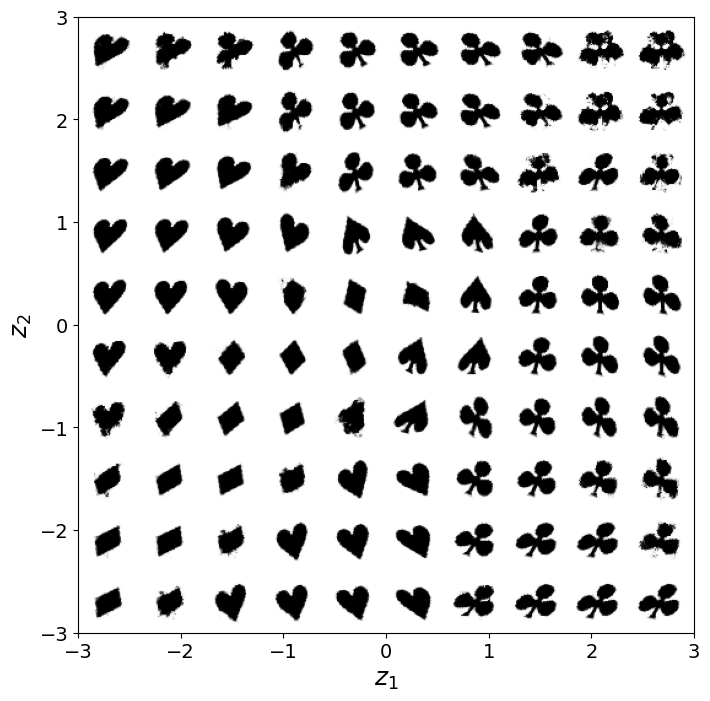

In [17]:
suits = ['♣', '♠', '♥', '♦', ]  # Card suits
z_loc, _ = model.encode(cards_train.reshape(-1, ws* ws))

mf = model.manifold2d(d=10, cmap='binary', z_coord=[-3,3,-3,3], dpi=50)

mf_np = rearrange_manifold(mf)

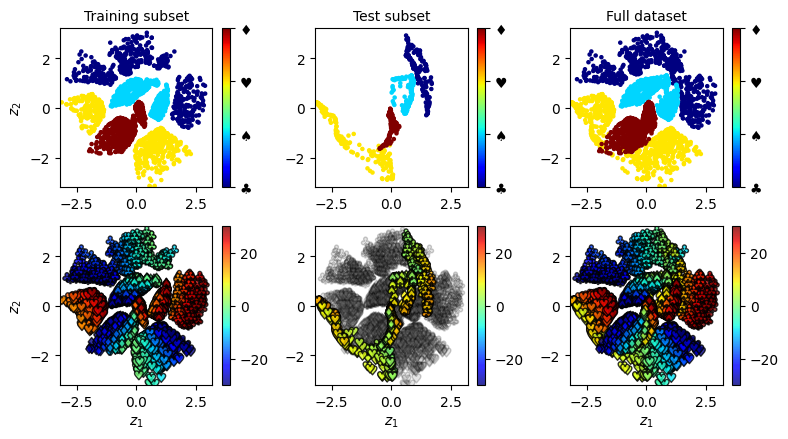

In [18]:
suit_markers = {0: '♣', 1: '♠', 2: '♥', 3: '♦'}
letters = ['a', 'b', 'c', 'd', 'e', 'f']

fig, ax = plt.subplots(2,3, figsize=(8, 4.5))

z_loc, _ = model.encode(cards_train.reshape(-1, ws* ws))

im = ax[0,0].scatter(z_loc[:, -2], z_loc[:, -1], s=5, c=labels_train, cmap='jet')
cbar = fig.colorbar(im, ax=ax[0,0])
cbar.set_ticks(np.linspace(0, 3, len(suits)))  # Set positions of labels
cbar.set_ticklabels(suits)
ax[0,0].set_title('Training subset', fontsize=10)
ax[0,1].set_title('Test subset', fontsize=10)

for suit_id, suit_marker in suit_markers.items():
  indices = np.where(labels_train == suit_id)
  scatter = ax[1,0].scatter(z_loc[indices, -2].numpy(), z_loc[indices, -1].numpy(),
             label=suit_marker, s=40, alpha=0.8, edgecolors='black',
             marker='$' + suit_marker + '$',
             c = angles_train[indices],
             vmin=-30,
             vmax=30,
             cmap='jet')  # Use Unicode marker as custom text

cbar = fig.colorbar(scatter, ax=ax[1,0])

for suit_id, suit_marker in suit_markers.items():
  indices = np.where(labels_train == suit_id)
  scatter = ax[1,1].scatter(z_loc[indices, -2].numpy(), z_loc[indices, -1].numpy(),
             label=suit_marker, s=40, alpha=0.2, edgecolors='black',
             marker='$' + suit_marker + '$',
             c = 'gray',
             )  # Use Unicode marker as custom text


z_loc, _ = model.encode(cards_test.reshape(-1, ws* ws))

im = ax[0,1].scatter(z_loc[:, -2], z_loc[:, -1], s=5, c=labels_test, cmap='jet')
cbar = fig.colorbar(im, ax=ax[0,1])
cbar.set_ticks(np.linspace(0, 3, len(suits)))  # Set positions of labels
cbar.set_ticklabels(suits)

for suit_id, suit_marker in suit_markers.items():
  indices = np.where(labels_test == suit_id)
  scatter = ax[1,1].scatter(z_loc[indices, -2].numpy(), z_loc[indices, -1].numpy(),
             label=suit_marker, s=40, alpha=0.8, edgecolors='black',
             marker='$' + suit_marker + '$',
             c = angles_test[indices],
             vmin=-30,
             vmax=30,
             cmap='jet')  # Use Unicode marker as custom text

cbar = fig.colorbar(scatter, ax=ax[1,1])

ax[0,2].set_title('Full dataset', fontsize=10)


z_loc, _ = model.encode(cards_all.reshape(-1, ws* ws))

im = ax[0,2].scatter(z_loc[:, -2], z_loc[:, -1],
                   c=labels_all,
                   cmap='jet',
                   s=5, )

cbar = fig.colorbar(im, ax=ax[0,2])
cbar.set_ticks(np.linspace(0, 3, len(suits)))  # Set positions of labels
cbar.set_ticklabels(suits)

for suit_id, suit_marker in suit_markers.items():
  indices = np.where(labels_all == suit_id)
  scatter = ax[1,2].scatter(z_loc[indices, -2].numpy(), z_loc[indices, -1].numpy(),
             label=suit_marker, s=40, alpha=0.8, edgecolors='black',
             marker='$' + suit_marker + '$',
             c = angles_all[indices],
             vmin=-30,
             vmax=30,
             cmap='jet')  # Use Unicode marker as custom text

cbar = fig.colorbar(scatter, ax=ax[1,2])

for _ in ax.flatten():
  _.set_xlim(-3.2, 3.2)
  _.set_ylim(-3.2, 3.2)

ax[0,0].set_ylabel('$z_2$', fontsize=10)
ax[1,0].set_ylabel('$z_2$', fontsize=10)
ax[1,0].set_xlabel('$z_1$', fontsize=10)
ax[1,1].set_xlabel('$z_1$', fontsize=10)
ax[1,2].set_xlabel('$z_1$', fontsize=10)

plt.tight_layout()

# for i, ax_ in enumerate(ax.flatten()):
#   ax_.text(-3, -2.8, f'({letters[i]})', fontsize=12)

fig.savefig('VAE_latent_space_gap.jpg', dpi=300, bbox_inches='tight')

#4. VAE + GP baseline on the frozen VAE latent space

This section provides a simple baseline requested for comparison with DKL-VAE. The VAE encoder is kept frozen. We first encode the training and test cards into the 2D VAE latent space, then fit an exact Gaussian Process regressor from latent coordinates to rotation angle. This tests whether a post-hoc GP on the standard VAE latent space can recover the angle dependence without target-aware latent-space training.


In [23]:
#@title VAE + GP baseline helper functions
# This baseline keeps the VAE frozen.
# The GP uses the same basic choice as the DKL-VAE notebook:
# ARD RBF kernel + Gaussian noise.
#
# Important:
# - The encoder mean is used as the latent coordinate.
# - The latent coordinates are standardized before GP fitting.
# - The target angle is standardized before GP fitting.
# - Predictions are transformed back to degrees.

def rbf_kernel_torch(X, Z, lengthscale, scale, noise=None, jitter=1e-6):
    """ARD RBF kernel."""
    Xs = X / lengthscale
    Zs = Z / lengthscale

    X2 = (Xs ** 2).sum(1, keepdim=True)
    Z2 = (Zs ** 2).sum(1, keepdim=True)

    r2 = (X2 - 2 * Xs @ Zs.T + Z2.T).clamp_min(0.0)
    K = scale * torch.exp(-0.5 * r2)

    if noise is not None and X.shape[0] == Z.shape[0] and torch.allclose(X, Z):
        K = K + (noise + jitter) * torch.eye(
            X.shape[0], dtype=X.dtype, device=X.device
        )

    return K


def negative_log_marginal_likelihood(z_train_std, y_train_std, log_length, log_scale, log_noise):
    """Exact GP negative log marginal likelihood."""
    lengthscale = torch.nn.functional.softplus(log_length) + 1e-5
    scale = torch.nn.functional.softplus(log_scale) + 1e-5
    noise = torch.nn.functional.softplus(log_noise) + 1e-6

    K = rbf_kernel_torch(
        z_train_std,
        z_train_std,
        lengthscale,
        scale,
        noise=noise,
        jitter=1e-6,
    )

    L = torch.linalg.cholesky(K)
    alpha = torch.cholesky_solve(y_train_std[:, None], L)

    nll = 0.5 * (y_train_std[:, None].T @ alpha).squeeze()
    nll = nll + torch.log(torch.diagonal(L)).sum()
    nll = nll + 0.5 * z_train_std.shape[0] * np.log(2 * np.pi)

    return nll


def fit_exact_gp_on_latent_space(z_train, y_train, n_steps=300, lr=0.05, print_every=50):
    """
    Fit an exact GP on frozen VAE latent coordinates.

    z_train: VAE encoder mean coordinates, not sampled z.
    y_train: rotation angles in degrees.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"

    z_train = torch.as_tensor(z_train, dtype=torch.float64, device=device)
    y_train = torch.as_tensor(y_train, dtype=torch.float64, device=device)

    eps = 1e-8

    # Standardize latent coordinates.
    z_mean = z_train.mean(dim=0, keepdim=True)
    z_std = z_train.std(dim=0, keepdim=True).clamp_min(eps)
    z_train_std = (z_train - z_mean) / z_std

    # Standardize target angle.
    y_mean = y_train.mean()
    y_std = y_train.std().clamp_min(eps)
    y_train_std = (y_train - y_mean) / y_std

    # ARD lengthscale: one value per latent dimension.
    # Initial softplus(0) ≈ 0.69, reasonable after standardization.
    log_length = torch.nn.Parameter(
        torch.zeros(z_train.shape[1], dtype=torch.float64, device=device)
    )

    # Initial softplus(0) ≈ 0.69.
    log_scale = torch.nn.Parameter(
        torch.tensor(0.0, dtype=torch.float64, device=device)
    )

    # Initial softplus(-2) ≈ 0.13.
    log_noise = torch.nn.Parameter(
        torch.tensor(-2.0, dtype=torch.float64, device=device)
    )

    optimizer = torch.optim.Adam([log_length, log_scale, log_noise], lr=lr)
    loss_history = []

    for step in range(n_steps):
        optimizer.zero_grad()

        loss = negative_log_marginal_likelihood(
            z_train_std,
            y_train_std,
            log_length,
            log_scale,
            log_noise,
        )

        loss.backward()
        optimizer.step()

        loss_history.append(float(loss.detach().cpu()))

        if print_every is not None and ((step + 1) % print_every == 0 or step == 0):
            print(f"Step {step + 1:04d} | GP NLL = {loss_history[-1]:.3f}")

    gp_params = {
        "z_train_std": z_train_std.detach(),
        "y_train_std": y_train_std.detach(),
        "z_mean": z_mean.detach(),
        "z_std": z_std.detach(),
        "y_mean": y_mean.detach(),
        "y_std": y_std.detach(),
        "lengthscale": (torch.nn.functional.softplus(log_length) + 1e-5).detach(),
        "scale": (torch.nn.functional.softplus(log_scale) + 1e-5).detach(),
        "noise": (torch.nn.functional.softplus(log_noise) + 1e-6).detach(),
        "loss_history": loss_history,
    }

    print("\nOptimized GP parameters:")
    print("lengthscale:", gp_params["lengthscale"].detach().cpu().numpy())
    print("scale:", float(gp_params["scale"].detach().cpu()))
    print("noise:", float(gp_params["noise"].detach().cpu()))

    return gp_params


def exact_gp_predict(z_new, gp_params, noiseless=True):
    """
    Predict mean and marginal variance for the exact GP.

    z_new: raw VAE encoder mean coordinates.
    Output mean is returned in degrees.
    """
    device = gp_params["z_train_std"].device

    z_new = torch.as_tensor(z_new, dtype=torch.float64, device=device)

    # Apply the same latent standardization as training.
    z_new_std = (z_new - gp_params["z_mean"]) / gp_params["z_std"]

    z_train_std = gp_params["z_train_std"]
    y_train_std = gp_params["y_train_std"]

    lengthscale = gp_params["lengthscale"]
    scale = gp_params["scale"]
    noise = gp_params["noise"]

    K_xx = rbf_kernel_torch(
        z_train_std,
        z_train_std,
        lengthscale,
        scale,
        noise=noise,
        jitter=1e-6,
    )

    K_xs = rbf_kernel_torch(
        z_train_std,
        z_new_std,
        lengthscale,
        scale,
        noise=None,
    )

    # For prediction of latent function use noiseless=True.
    # For predictive observation uncertainty, set noiseless=False.
    K_ss = rbf_kernel_torch(
        z_new_std,
        z_new_std,
        lengthscale,
        scale,
        noise=None if noiseless else noise,
        jitter=1e-6,
    )

    L = torch.linalg.cholesky(K_xx)
    alpha = torch.cholesky_solve(y_train_std[:, None], L)

    mean_std = K_xs.T @ alpha

    v = torch.linalg.solve_triangular(L, K_xs, upper=False)
    cov_std = K_ss - v.T @ v

    mean = mean_std.squeeze() * gp_params["y_std"] + gp_params["y_mean"]
    var = torch.diagonal(cov_std).clamp_min(0.0) * (gp_params["y_std"] ** 2)

    return mean.detach().cpu(), var.detach().cpu()


def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_residual = np.sum((y_true - y_pred) ** 2)

    if ss_total == 0:
        return np.nan

    return 1 - (ss_residual / ss_total)


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return np.sqrt(np.mean((y_true - y_pred) ** 2))

In [24]:
#@title Encode cards with frozen VAE and fit GP on the training subset
# The model used here is the subset-trained VAE from Section 3.
# Training data: angles in [-30, 0] and [15, 30] deg.
# Test data: held-out gap with angles in [0, 15] deg.
#
# We use the encoder mean, not sampled latent coordinates.
# Latent and target standardization are handled inside fit_exact_gp_on_latent_space().

model.eval()

with torch.no_grad():
    mu_train_vae, _ = model.encode(cards_train.reshape(-1, ws * ws))
    mu_test_vae, _ = model.encode(cards_test.reshape(-1, ws * ws))

mu_train_vae = mu_train_vae.detach().cpu().numpy()
mu_test_vae = mu_test_vae.detach().cpu().numpy()

y_train_gp = angles_train.detach().cpu().numpy()
y_test_gp = angles_test.detach().cpu().numpy()

print("Train angle range:", y_train_gp.min(), y_train_gp.max())
print("Test angle range:", y_test_gp.min(), y_test_gp.max())
print("VAE latent train shape:", mu_train_vae.shape)
print("VAE latent test shape:", mu_test_vae.shape)

# For exact reproducibility/compatibility, use all encoded training points.
# If this is too slow on CPU, set max_gp_points to a smaller integer, e.g. 1200.
max_gp_points = None

if max_gp_points is not None and len(mu_train_vae) > max_gp_points:
    rng = np.random.default_rng(0)
    idx_gp = rng.choice(len(mu_train_vae), size=max_gp_points, replace=False)

    z_train_gp = mu_train_vae[idx_gp]
    y_train_gp_fit = y_train_gp[idx_gp]
else:
    z_train_gp = mu_train_vae
    y_train_gp_fit = y_train_gp

vae_gp_params = fit_exact_gp_on_latent_space(
    z_train_gp,
    y_train_gp_fit,
    n_steps=300,
    lr=0.05,
    print_every=50,
)

# Use noiseless=True for the latent function prediction used in RMSE/R2.
# This gives the GP posterior mean without adding observation noise to the predictive variance.
vae_gp_mean, vae_gp_var = exact_gp_predict(
    mu_test_vae,
    vae_gp_params,
    noiseless=True,
)

vae_gp_mean = vae_gp_mean.numpy()
vae_gp_std = np.sqrt(vae_gp_var.numpy())

print("\nPrediction sanity check:")
print("True test angle range:", y_test_gp.min(), y_test_gp.max())
print("Predicted angle range:", vae_gp_mean.min(), vae_gp_mean.max())
print("True test mean/std:", y_test_gp.mean(), y_test_gp.std())
print("Predicted mean/std:", vae_gp_mean.mean(), vae_gp_mean.std())


Train angle range: -29.995578034013633 29.997841112556145
Test angle range: 0.032247528188158014 14.946036398983196
VAE latent train shape: (2278, 2)
VAE latent test shape: (722, 2)
Step 0001 | GP NLL = 568.642
Step 0050 | GP NLL = -2049.898
Step 0100 | GP NLL = -3465.866
Step 0150 | GP NLL = -3807.762
Step 0200 | GP NLL = -3814.792
Step 0250 | GP NLL = -3814.806
Step 0300 | GP NLL = -3814.806

Optimized GP parameters:
lengthscale: [0.15370693 0.15856348]
scale: 0.31294246788047625
noise: 0.00027558780643468714

Prediction sanity check:
True test angle range: 0.032247528188158014 14.946036398983196
Predicted angle range: -28.90344327489842 30.525137093466025
True test mean/std: 7.4633641360434675 4.377142364414746
Predicted mean/std: 5.162677266366017 9.894868470535272


In [27]:
import pandas as pd

In [28]:
#@title VAE + GP baseline metrics on the held-out angle gap

suit_markers = {0: '♣', 1: '♠', 2: '♥', 3: '♦'}
labels_test_np = labels_test.detach().cpu().numpy()

print('VAE + GP baseline: prediction of the held-out [0, 15] degree gap')
print('RMSE is in degrees; R2 is unitless.\n')

print('Sanity check:')
print('True angle range:     ', round(float(np.min(y_test_gp)), 2), 'to', round(float(np.max(y_test_gp)), 2))
print('Predicted angle range:', round(float(np.min(vae_gp_mean)), 2), 'to', round(float(np.max(vae_gp_mean)), 2))
print('True mean/std:        ', round(float(np.mean(y_test_gp)), 2), '/', round(float(np.std(y_test_gp)), 2))
print('Predicted mean/std:   ', round(float(np.mean(vae_gp_mean)), 2), '/', round(float(np.std(vae_gp_mean)), 2))
print()

rows = []

for suit_id, suit_marker in suit_markers.items():
    mask = labels_test_np == suit_id

    if np.sum(mask) == 0:
        rows.append([suit_marker, 0, np.nan, np.nan])
        continue

    rmse_value = rmse(y_test_gp[mask], vae_gp_mean[mask])
    r2_value = r2_score(y_test_gp[mask], vae_gp_mean[mask])

    rows.append([
        suit_marker,
        int(np.sum(mask)),
        rmse_value,
        r2_value,
    ])

rows.append([
    'All suits',
    int(len(y_test_gp)),
    rmse(y_test_gp, vae_gp_mean),
    r2_score(y_test_gp, vae_gp_mean),
])

metrics_df = pd.DataFrame(
    rows,
    columns=['Subset', 'N', 'RMSE, degrees', 'R², unitless']
)

display(metrics_df.round({
    'RMSE, degrees': 2,
    'R², unitless': 2,
}))


VAE + GP baseline: prediction of the held-out [0, 15] degree gap
RMSE is in degrees; R2 is unitless.

Sanity check:
True angle range:      0.03 to 14.95
Predicted angle range: -28.9 to 30.53
True mean/std:         7.46 / 4.38
Predicted mean/std:    5.16 / 9.89



,Subset,N,"RMSE, degrees","R², unitless"
0,♣,193,9.69,-4.18
1,♠,164,5.86,-0.74
2,♥,188,12.59,-7.33
3,♦,177,2.91,0.57
4,All suits,722,8.73,-2.98


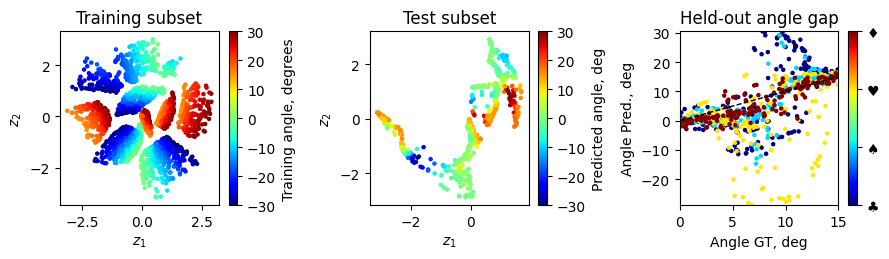

In [34]:
#@title Visualize VAE + GP predictions in the frozen VAE latent space

fig, ax = plt.subplots(1, 3, figsize=(9, 2.7))

# Panel 1: frozen VAE latent space for training subset
im0 = ax[0].scatter(
    mu_train_vae[:, -2],
    mu_train_vae[:, -1],
    s=5,
    c=y_train_gp,
    cmap='jet',
    vmin=-30,
    vmax=30,
)

fig.colorbar(im0, ax=ax[0], label='Training angle, degrees')
ax[0].set_title('Training subset')

# Panel 2: GP predictions on the held-out test subset
im1 = ax[1].scatter(
    mu_test_vae[:, -2],
    mu_test_vae[:, -1],
    s=5,
    c=vae_gp_mean,
    cmap='jet',
    vmin=-30,
    vmax=30,
)

fig.colorbar(im1, ax=ax[1], label='Predicted angle, deg')
ax[1].set_title('Test subset')

# Panel 3: predicted vs. ground-truth angle
im2 = ax[2].scatter(
    y_test_gp,
    vae_gp_mean,
    c=labels_test_np,
    cmap='jet',
    s=5,
)

cbar = fig.colorbar(im2, ax=ax[2])
cbar.set_ticks(list(suit_markers.keys()))
cbar.set_ticklabels(list(suit_markers.values()))
#cbar.set_label('Card suit')

ax[2].plot([0, 15], [0, 15], '--', color='black', linewidth=1)

# Optional: allow predictions outside the physical test range to be visible.
pred_min = min(0, np.nanmin(vae_gp_mean))
pred_max = max(15, np.nanmax(vae_gp_mean))

ax[2].set_xlim(0, 15)
ax[2].set_ylim(pred_min, pred_max)

ax[2].set_xlabel('Angle GT, deg')
ax[2].set_ylabel('Angle Pred., deg')
ax[2].set_title('Held-out angle gap')

for a in ax[:2]:
    a.set_xlabel('$z_1$')
    a.set_ylabel('$z_2$')

plt.tight_layout()
plt.show()
fig.savefig('VAE_GP_baseline_gap_prediction.jpg', dpi=300, bbox_inches='tight')
